# Multi-Touch Marketing Attribution Model

## 1. Problem Statement
Businesses struggle to understand which marketing channels drive conversions.
This project builds a multi-touch attribution model to assign conversion credit
across customer journey touchpoints.

## 2. Dataset Description
This dataset contains customer interaction data across marketing channels.

Columns:
- user_id → unique customer identifier
- timestamp → interaction time
- channel → marketing channel used
- campaign → campaign name
- conversion → whether the user converted (Yes/No)

In [54]:
from google.colab import files
uploaded = files.upload()

Saving multi_touch_attribution_data.csv to multi_touch_attribution_data (4).csv


In [55]:
import pandas as pd

In [73]:
import io
df = pd.read_csv(io.BytesIO(uploaded['multi_touch_attribution_data (4).csv']))

In [57]:
df.head()

,User ID,Timestamp,Channel,Campaign,Conversion
0,83281,2025-02-10 07:58:51,Email,New Product Launch,No
1,68071,2025-02-10 23:38:48,Search Ads,Winter Sale,No
2,90131,2025-02-11 10:41:07,Social Media,Brand Awareness,Yes
3,71026,2025-02-10 08:19:44,Direct Traffic,-,Yes
4,94486,2025-02-10 15:15:46,Email,Retargeting,Yes


## 3. Data Cleaning
Steps performed:
- Converted timestamp to datetime
- Converted conversion values from Yes/No to 1/0
- Sorted customer journeys by time
- Filtered converting users

In [58]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [59]:
df["Conversion"] = df["Conversion"].map( {"Yes":1, "No":0, "yes":1, "no":0})

In [60]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values(["User ID", "Timestamp"])
df.head()

,User ID,Timestamp,Channel,Campaign,Conversion
8297,10028,2025-02-10 01:44:12,Search Ads,Discount Offer,1
3633,10028,2025-02-11 01:03:57,Display Ads,-,1
9486,10045,2025-02-10 17:20:43,Search Ads,Discount Offer,0
7663,10045,2025-02-11 18:44:15,Display Ads,New Product Launch,1
8643,10062,2025-02-10 15:42:42,Social Media,Brand Awareness,0


In [61]:
converted_users = df[df["Conversion"] == 1]["User ID"].unique()
df = df[df["User ID"].isin(converted_users)]

## 4. Customer Journey Creation
Customer journeys were built by grouping interactions by user
and creating channel sequences representing each path to conversion.

In [62]:
paths = df.groupby("User ID")["Channel"].apply(list)
paths.head()

,Channel
User ID,
10028,"[Search Ads, Display Ads]"
10045,"[Search Ads, Display Ads]"
10062,"[Social Media, Direct Traffic, Email]"
10068,"[Search Ads, Social Media, Social Media, Searc..."
10095,"[Display Ads, Email, Referral, Display Ads, Se..."


## 5. Attribution Models
The following attribution models were implemented:
- First Click Attribution
- Last Click Attribution
- Linear Attribution
- Time Decay Attribution

In [63]:
first_click = {}
for path in paths:
    first_click[path[0]] = first_click.get(path[0], 0) + 1
first_click

{'Search Ads': 371,
 'Social Media': 389,
 'Display Ads': 428,
 'Referral': 408,
 'Email': 374,
 'Direct Traffic': 411}

In [64]:
last_click = {}
for path in paths:
    last_click[path[-1]] = last_click.get(path[-1], 0) + 1
last_click

{'Display Ads': 401,
 'Email': 393,
 'Social Media': 383,
 'Referral': 384,
 'Direct Traffic': 425,
 'Search Ads': 395}

In [65]:
linear = {}
for path in paths:
    credit = 1 / len(path)
    for Channel in path:
        linear[Channel] = linear.get(Channel, 0) + credit
linear

{'Search Ads': 381.5418470418453,
 'Display Ads': 407.15616883116786,
 'Social Media': 397.6037157287149,
 'Direct Traffic': 408.2765512265493,
 'Email': 387.7167748917735,
 'Referral': 398.7049422799413}

In [66]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values(["User ID", "Timestamp"])

converted_users = df[df["Conversion"] == 1]["User ID"].unique()
df = df[df["User ID"].isin(converted_users)]

paths = df.groupby("User ID")["Channel"].apply(list)

paths.head()

,Channel
User ID,
10028,"[Search Ads, Display Ads]"
10045,"[Search Ads, Display Ads]"
10062,"[Social Media, Direct Traffic, Email]"
10068,"[Search Ads, Social Media, Social Media, Searc..."
10095,"[Display Ads, Email, Referral, Display Ads, Se..."


In [67]:
import numpy as np

time_decay = {}
for path in paths:
  weights = np.linspace(0.1, 1, len(path))
  weights = weights / weights.sum()
  for channel, weight in zip(path, weights):
    time_decay[channel]=time_decay.get(channel, 0) + weight
time_decay

{'Search Ads': np.float64(389.34556605011215),
 'Display Ads': np.float64(399.42538370720274),
 'Social Media': np.float64(397.79973107700386),
 'Direct Traffic': np.float64(413.31657483930286),
 'Email': np.float64(394.87341597796257),
 'Referral': np.float64(386.2393283484197)}

## 6. Results
Channel performance was compared across different attribution models
to identify which channels contribute most to conversions.

In [68]:
results = pd.DataFrame({
    "First Click": pd.Series(first_click),
    "Last Click": pd.Series(last_click),
    "Linear": pd.Series(linear),
    "Time Decay": pd.Series(time_decay)
}).fillna(0)

results

,First Click,Last Click,Linear,Time Decay
Direct Traffic,411,425,408.276551,413.316575
Display Ads,428,401,407.156169,399.425384
Email,374,393,387.716775,394.873416
Referral,408,384,398.704942,386.239328
Search Ads,371,395,381.541847,389.345566
Social Media,389,383,397.603716,397.799731


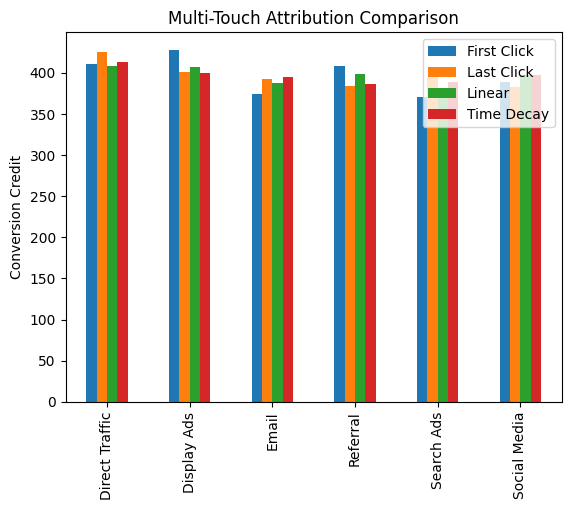

In [69]:
import matplotlib.pyplot as plt
results.plot(kind="bar")
plt.title("Multi-Touch Attribution Comparison")
plt.ylabel("Conversion Credit")
plt.show()

## 7. Business Insights
Different attribution models produce different channel valuations.
This highlights the importance of multi-touch attribution in marketing
budget allocation and performance optimization.

In [70]:
# Last click shows Meta strongest.
# Linear shows Email contributes earlier.
# Marketing teams should not rely only on last-click attribution.